In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
dataset1 = pd.read_csv('/content/drive/MyDrive/Data 1 - Sheet1.csv')
X = dataset1[['Input']].values
y = dataset1[['Output']].values

In [ ]:
dataset1.head()

,Input,Output
0,7,61
1,7,62
2,5,63
3,6,6
4,78,4


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=33)

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# Name: PRAVEEN RAJ R
# Register Number: 212224230207
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(1,8)
        self.fc2=nn.Linear(8,10)
        self.fc3=nn.Linear(10,1)
        self.relu=nn.ReLU()
        self.history={'loss':[]}

  def forward(self,x):
    x=self.relu(self.fc1(x))
    x=self.relu(self.fc2(x))
    x=self.fc3(x)
    return x






In [ ]:
# Initialize the Model, Loss Function, and Optimizer
# Write your code here
lig = NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.Adam(lig.parameters(), lr=0.001)#lr=learning rate

In [ ]:
# Name:PRAVEEN RAJ R
# Register NumAber: 212224230207
def train_model(lig, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss=criterion(lig(X_train),y_train)
        loss.backward()
        optimizer.step()


        lig.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')


In [ ]:
train_model(lig,X_train_tensor, y_train_tensor, criterion, optimizer)


Epoch [0/2000], Loss: 7864.050781
Epoch [200/2000], Loss: 7574.716797
Epoch [400/2000], Loss: 6216.056152
Epoch [600/2000], Loss: 4278.302734
Epoch [800/2000], Loss: 3371.881104
Epoch [1000/2000], Loss: 3004.670898
Epoch [1200/2000], Loss: 2791.088623
Epoch [1400/2000], Loss: 2639.677490
Epoch [1600/2000], Loss: 2524.031006
Epoch [1800/2000], Loss: 2433.546143


In [ ]:
with torch.no_grad():
    test_loss = criterion(lig(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')


Test Loss: 6978.036621


In [ ]:
loss_df = pd.DataFrame(lig.history)

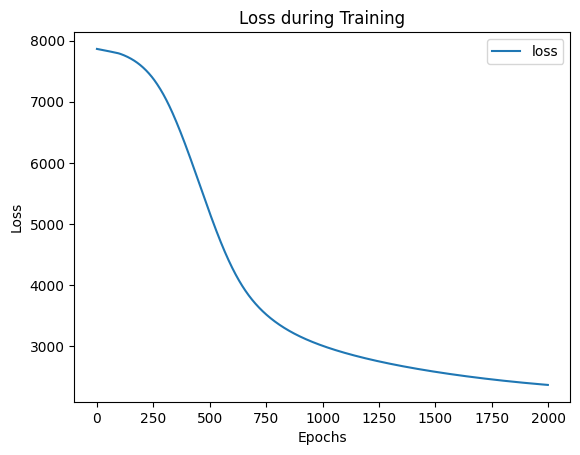

In [ ]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [ ]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = lig(torch.tensor(scaler.transform(X_n1_1), dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 77.9225845336914
